# Batch Normalization from Scratch (NumPy)

This notebook implements **Batch Normalization** (Ioffe & Szegedy, 2015) from the ground up in pure NumPy, plugs it into a small MLP, and compares training dynamics with and without BN on a 2-D toy classification task.

**Paper:** [Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift](https://arxiv.org/abs/1502.03167)

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

## 2. Data: make_moons

In [2]:
X, y = make_moons(n_samples=1200, noise=0.25, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

def one_hot(y, num_classes=2):
    return np.eye(num_classes)[y]

Y_train = one_hot(y_train)
Y_val = one_hot(y_val)

print("Train:", X_train.shape, "Val:", X_val.shape)

Train: (960, 2) Val: (240, 2)


## 3. Building blocks

### 3.1 Linear layer

In [3]:
class Linear:
    def __init__(self, in_features, out_features, use_bias=True, scale=0.01):
        self.W = np.random.randn(in_features, out_features) * scale
        self.b = np.zeros((1, out_features)) if use_bias else None
        self.use_bias = use_bias

    def forward(self, x):
        self.x = x
        out = x @ self.W
        if self.use_bias:
            out = out + self.b
        return out

    def backward(self, dout):
        self.dW = self.x.T @ dout / self.x.shape[0]
        if self.use_bias:
            self.db = np.mean(dout, axis=0, keepdims=True)
        self.dx = dout @ self.W.T
        return self.dx

    def step(self, lr):
        self.W -= lr * self.dW
        if self.use_bias:
            self.b -= lr * self.db

### 3.2 Batch Normalization (Algorithm 1 from the paper)

In [4]:
class BatchNorm1D:
    def __init__(self, num_features, eps=1e-5, momentum=0.9):
        self.eps = eps
        self.momentum = momentum
        self.gamma = np.ones((1, num_features))
        self.beta = np.zeros((1, num_features))
        self.running_mean = np.zeros((1, num_features))
        self.running_var = np.ones((1, num_features))
        self.training = True

    def forward(self, x):
        self.x = x
        if self.training:
            self.mu = np.mean(x, axis=0, keepdims=True)
            self.var = np.var(x, axis=0, keepdims=True)
            self.x_hat = (x - self.mu) / np.sqrt(self.var + self.eps)
            self.y = self.gamma * self.x_hat + self.beta
            m = x.shape[0]
            unbiased_var = self.var * (m / (m - 1)) if m > 1 else self.var
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * self.mu
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * unbiased_var
        else:
            x_hat = (x - self.running_mean) / np.sqrt(self.running_var + self.eps)
            self.y = self.gamma * x_hat + self.beta
        return self.y

    def backward(self, dout):
        m = self.x.shape[0]
        x_mu = self.x - self.mu
        inv_sqrt = 1.0 / np.sqrt(self.var + self.eps)
        self.dgamma = np.sum(dout * self.x_hat, axis=0, keepdims=True)
        self.dbeta = np.sum(dout, axis=0, keepdims=True)
        dx_hat = dout * self.gamma
        dvar = np.sum(dx_hat * x_mu * (-0.5) * inv_sqrt**3, axis=0, keepdims=True)
        dmu = np.sum(dx_hat * (-inv_sqrt), axis=0, keepdims=True) + dvar * np.mean(-2 * x_mu, axis=0, keepdims=True)
        dx = dx_hat * inv_sqrt + dvar * 2 * x_mu / m + dmu / m
        return dx

    def step(self, lr):
        self.gamma -= lr * self.dgamma
        self.beta -= lr * self.dbeta

    def train(self):
        self.training = True

    def eval(self):
        self.training = False

### 3.3 Activations

In [5]:
class ReLU:
    def forward(self, x):
        self.x = x
        return np.maximum(0, x)

    def backward(self, dout):
        return dout * (self.x > 0).astype(float)

class Tanh:
    def forward(self, x):
        self.out = np.tanh(x)
        return self.out

    def backward(self, dout):
        return dout * (1 - self.out**2)

### 3.4 Softmax + cross-entropy

In [6]:
class SoftmaxCrossEntropy:
    def forward(self, logits, y_true):
        self.y_true = y_true
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        exp = np.exp(shifted)
        self.probs = exp / np.sum(exp, axis=1, keepdims=True)
        self.logits = logits
        return -np.mean(np.sum(y_true * np.log(self.probs + 1e-8), axis=1))

    def backward(self):
        return (self.probs - self.y_true) / self.y_true.shape[0]

def accuracy(probs, y_true_labels):
    return np.mean(np.argmax(probs, axis=1) == y_true_labels)

## 4. MLP model

In [7]:
class MLPClassifier:
    def __init__(self, use_bn=True, activation='relu', hidden=[64, 64, 64]):
        self.use_bn = use_bn
        self.activation_name = activation
        act = ReLU if activation == 'relu' else Tanh
        self.layers = []
        dims = [2] + hidden + [2]
        for i in range(len(dims) - 1):
            is_last = (i == len(dims) - 2)
            use_bias = not (use_bn and not is_last)
            self.layers.append(Linear(dims[i], dims[i+1], use_bias=use_bias, scale=0.1))
            if not is_last:
                if use_bn:
                    self.layers.append(BatchNorm1D(dims[i+1]))
                self.layers.append(act())
        self.criterion = SoftmaxCrossEntropy()

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def compute_loss(self, logits, y_true):
        return self.criterion.forward(logits, y_true)

    def backward(self):
        dout = self.criterion.backward()
        for layer in reversed(self.layers):
            if hasattr(layer, 'backward'):
                dout = layer.backward(dout)
        return dout

    def step(self, lr):
        for layer in self.layers:
            if hasattr(layer, 'step'):
                layer.step(lr)

    def train_mode(self):
        for layer in self.layers:
            if hasattr(layer, 'train'):
                layer.train()

    def eval_mode(self):
        for layer in self.layers:
            if hasattr(layer, 'eval'):
                layer.eval()

## 5. Training utilities

In [8]:
def get_batches(x, y, batch_size=32, shuffle=True):
    idx = np.arange(x.shape[0])
    if shuffle:
        np.random.shuffle(idx)
    for start in range(0, x.shape[0], batch_size):
        end = start + batch_size
        yield x[idx[start:end]], y[idx[start:end]]

def evaluate(model, X, Y, y_labels):
    model.eval_mode()
    logits = model.forward(X)
    loss = model.compute_loss(logits, Y)
    acc = accuracy(model.criterion.probs, y_labels)
    model.train_mode()
    return loss, acc

def train_model(model, X_train, Y_train, X_val, Y_val, y_train, y_val,
                lr=0.05, epochs=150, batch_size=32, record_every=5):
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'epochs_recorded': []}
    for epoch in range(epochs):
        epoch_losses = []
        model.train_mode()
        for xb, yb in get_batches(X_train, Y_train, batch_size):
            logits = model.forward(xb)
            loss = model.compute_loss(logits, yb)
            epoch_losses.append(loss)
            model.backward()
            model.step(lr)
        if (epoch + 1) % record_every == 0 or epoch == 0:
            vloss, vacc = evaluate(model, X_val, Y_val, y_val)
            history['train_loss'].append(np.mean(epoch_losses))
            history['val_loss'].append(vloss)
            history['val_acc'].append(vacc)
            history['epochs_recorded'].append(epoch + 1)
    return history

## 6. Train two networks side by side

In [9]:
EPOCHS = 150
BATCH_SIZE = 32
LR_PLAIN = 0.05
LR_BN = 0.25

plain_net = MLPClassifier(use_bn=False, activation='relu')
bn_net = MLPClassifier(use_bn=True, activation='relu')

print("Training plain network...")
hist_plain = train_model(plain_net, X_train, Y_train, X_val, Y_val,
                          y_train, y_val, lr=LR_PLAIN, epochs=EPOCHS, batch_size=BATCH_SIZE)

print("Training BN network (5x learning rate)...")
hist_bn = train_model(bn_net, X_train, Y_train, X_val, Y_val,
                       y_train, y_val, lr=LR_BN, epochs=EPOCHS, batch_size=BATCH_SIZE)

Training plain network...


Training BN network (5x learning rate)...


## 7. Compare training curves

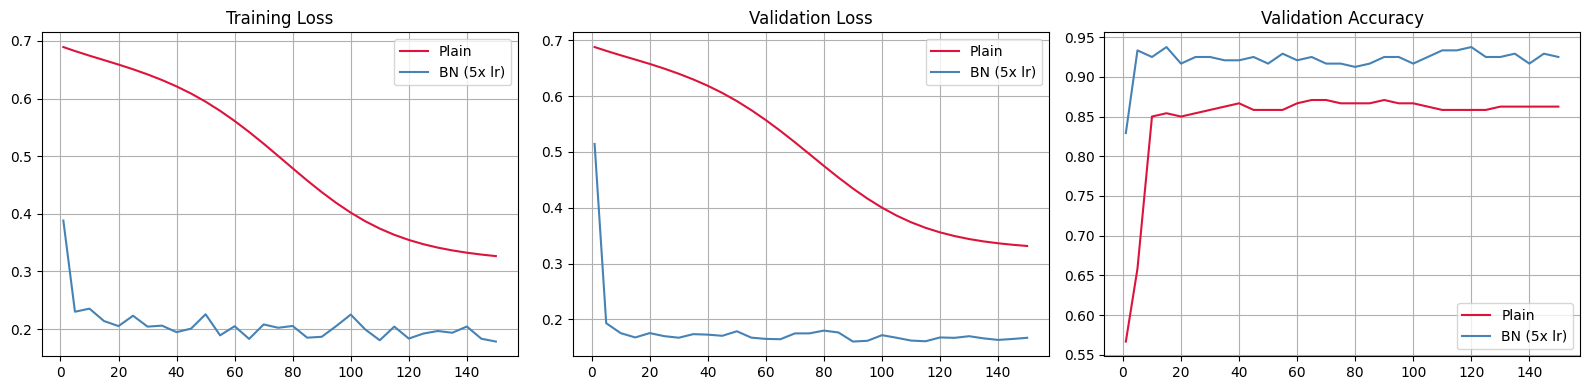

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_plain['epochs_recorded'], hist_plain['train_loss'], label='Plain', color='crimson')
axes[0].plot(hist_bn['epochs_recorded'], hist_bn['train_loss'], label='BN (5x lr)', color='steelblue')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(hist_plain['epochs_recorded'], hist_plain['val_loss'], label='Plain', color='crimson')
axes[1].plot(hist_bn['epochs_recorded'], hist_bn['val_loss'], label='BN (5x lr)', color='steelblue')
axes[1].set_title('Validation Loss')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(hist_plain['epochs_recorded'], hist_plain['val_acc'], label='Plain', color='crimson')
axes[2].plot(hist_bn['epochs_recorded'], hist_bn['val_acc'], label='BN (5x lr)', color='steelblue')
axes[2].set_title('Validation Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 8. Activation distribution: BN keeps inputs stable

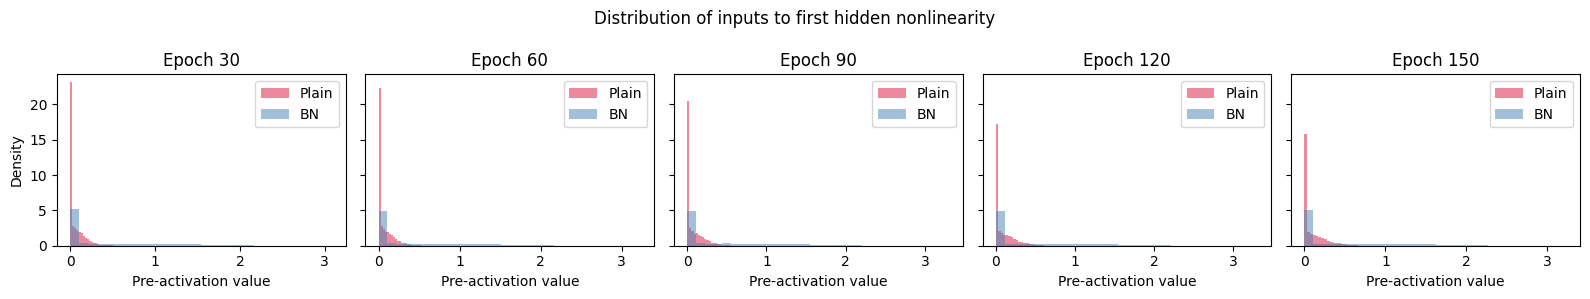

In [11]:
def capture_pre_activation(model, X):
    model.eval_mode()
    x = X
    for layer in model.layers:
        x = layer.forward(x)
        if isinstance(layer, (ReLU, Tanh)):
            break
    model.train_mode()
    return x.flatten()

plain_snaps, bn_snaps = [], []
plain_net2 = MLPClassifier(use_bn=False, activation='relu')
bn_net2 = MLPClassifier(use_bn=True, activation='relu')

for e in range(EPOCHS):
    for xb, yb in get_batches(X_train, Y_train, BATCH_SIZE):
        logits = plain_net2.forward(xb)
        plain_net2.compute_loss(logits, yb)
        plain_net2.backward()
        plain_net2.step(LR_PLAIN)

        logits = bn_net2.forward(xb)
        bn_net2.compute_loss(logits, yb)
        bn_net2.backward()
        bn_net2.step(LR_BN)

    if (e + 1) % 30 == 0:
        plain_snaps.append(capture_pre_activation(plain_net2, X_val))
        bn_snaps.append(capture_pre_activation(bn_net2, X_val))

fig, axes = plt.subplots(1, len(plain_snaps), figsize=(16, 3), sharey=True)
for i, (p, b) in enumerate(zip(plain_snaps, bn_snaps)):
    axes[i].hist(p, bins=30, alpha=0.5, label='Plain', color='crimson', density=True)
    axes[i].hist(b, bins=30, alpha=0.5, label='BN', color='steelblue', density=True)
    axes[i].set_title(f'Epoch {(i+1)*30}')
    axes[i].set_xlabel('Pre-activation value')
    axes[i].legend()
axes[0].set_ylabel('Density')
plt.suptitle('Distribution of inputs to first hidden nonlinearity')
plt.tight_layout()
plt.show()

## 9. Bonus: BN rescues a saturating nonlinearity (Tanh)

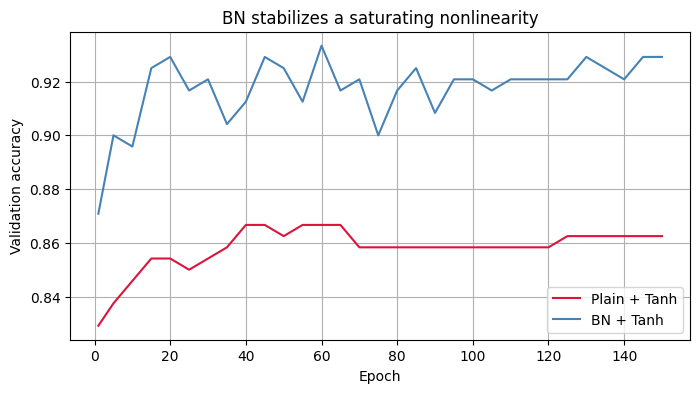

In [12]:
plain_tanh = MLPClassifier(use_bn=False, activation='tanh')
bn_tanh = MLPClassifier(use_bn=True, activation='tanh')

hist_plain_tanh = train_model(plain_tanh, X_train, Y_train, X_val, Y_val,
                               y_train, y_val, lr=LR_PLAIN, epochs=EPOCHS, batch_size=BATCH_SIZE)
hist_bn_tanh = train_model(bn_tanh, X_train, Y_train, X_val, Y_val,
                            y_train, y_val, lr=LR_BN, epochs=EPOCHS, batch_size=BATCH_SIZE)

plt.figure(figsize=(8, 4))
plt.plot(hist_plain_tanh['epochs_recorded'], hist_plain_tanh['val_acc'], label='Plain + Tanh', color='crimson')
plt.plot(hist_bn_tanh['epochs_recorded'], hist_bn_tanh['val_acc'], label='BN + Tanh', color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Validation accuracy')
plt.title('BN stabilizes a saturating nonlinearity')
plt.legend()
plt.grid(True)
plt.show()

## 10. Inference sanity check

In [13]:
plain_net.eval_mode()
bn_net.eval_mode()

logits_plain = plain_net.forward(X_val)
loss_plain = plain_net.compute_loss(logits_plain, Y_val)
acc_plain = accuracy(plain_net.criterion.probs, y_val)

logits_bn = bn_net.forward(X_val)
loss_bn = bn_net.compute_loss(logits_bn, Y_val)
acc_bn = accuracy(bn_net.criterion.probs, y_val)

print(f"Plain net -- val loss: {loss_plain:.4f}, val acc: {acc_plain:.4f}")
print(f"BN net    -- val loss: {loss_bn:.4f}, val acc: {acc_bn:.4f}")

for layer in bn_net.layers:
    if isinstance(layer, BatchNorm1D):
        print("\nFirst BN layer:")
        print("gamma:", layer.gamma.flatten())
        print("beta :", layer.beta.flatten())
        print("running mean:", layer.running_mean.flatten())
        print("running var :", layer.running_var.flatten())
        break

Plain net -- val loss: 0.3314, val acc: 0.8625
BN net    -- val loss: 0.1669, val acc: 0.9250

First BN layer:
gamma: [1.10928374 1.07306774 1.02612642 1.01557647 0.52362274 0.92014889
 1.03196254 0.8644804  1.21060461 1.0335127  0.81422292 1.22841124
 1.10981532 1.13650198 1.06167511 1.13609301 1.06012638 1.02247689
 0.66738654 0.99795936 1.03923527 1.11946425 0.87759757 0.90717278
 1.20867332 0.80158829 0.77012726 0.93845723 0.81453383 0.70565705
 1.16435776 0.79041497 0.88687045 0.83746874 0.81802503 0.92268174
 1.10605283 0.76971104 0.73965496 1.07387372 1.1298833  1.14267752
 0.91003304 1.15513415 0.99207035 1.13091024 1.08742426 0.92742531
 0.94521698 1.11625675 1.05642986 0.97961524 1.38064397 1.15125903
 1.04063403 1.11401786 1.28749405 1.03192893 1.30872112 0.97152885
 0.88276679 0.81581142 1.09093539 0.88428242]
beta : [ 0.23198317  0.412601   -0.06480328 -0.11621991 -0.09828775  0.16003784
 -0.01591951 -0.20029368 -0.03018021 -0.17925829  0.24510016  0.01559656
 -0.23879593 

## 11. Takeaways

1. Batch Normalization standardizes layer inputs on every mini-batch, keeping activation distributions stable and allowing much higher learning rates.
2. The learned `gamma` and `beta` give the network freedom to undo normalization when identity is optimal.
3. Backprop through the mini-batch mean and variance is essential; treating BN as fixed preprocessing would make parameters explode.
4. At inference, BN becomes a deterministic affine transform using population statistics accumulated during training.
5. BN is not only about covariate shift — later research showed it also smooths the loss landscape, but the original algorithm remains the backbone of modern normalization layers.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
